Install packages

In [1]:
!pip -q install pandas numpy scikit-learn matplotlib seaborn openpyxl

Import libraries and mount Drive

In [3]:
import os
import json
import platform
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

warnings.filterwarnings("ignore")

drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/BSc Thesis"
OUTPUT_DIR = f"{PROJECT_DIR}/final_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("Output folder:", OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder: /content/drive/MyDrive/BSc Thesis
Output folder: /content/drive/MyDrive/BSc Thesis/final_outputs


Identify the target/label column

In [5]:
import os
import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/BSc Thesis"

csv_files = []

for root, dirs, files in os.walk(PROJECT_DIR):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:")
for file in csv_files:
    print(file)

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV file found. Put Drebin-Dataset.csv inside Google Drive > MyDrive > BSc Thesis."
    )

DATASET_PATH = csv_files[0]

df = pd.read_csv(DATASET_PATH, low_memory=False)

print("\nDataset loaded successfully.")
print("Dataset path:", DATASET_PATH)
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

CSV files found:
/content/drive/MyDrive/BSc Thesis/Drebin Dataset.csv

Dataset loaded successfully.
Dataset path: /content/drive/MyDrive/BSc Thesis/Drebin Dataset.csv
Dataset shape: (7255, 216)

Column names:
['transact', 'onServiceConnected', 'bindService', 'attachInterface', 'ServiceConnection', 'android.os.Binder', 'SEND_SMS', 'Ljava.lang.Class.getCanonicalName', 'Ljava.lang.Class.getMethods', 'Ljava.lang.Class.cast', 'Ljava.net.URLDecoder', 'android.content.pm.Signature', 'android.telephony.SmsManager', 'READ_PHONE_STATE', 'getBinder', 'ClassLoader', 'Landroid.content.Context.registerReceiver', 'Ljava.lang.Class.getField', 'Landroid.content.Context.unregisterReceiver', 'GET_ACCOUNTS', 'RECEIVE_SMS', 'Ljava.lang.Class.getDeclaredField', 'READ_SMS', 'getCallingUid', 'Ljavax.crypto.spec.SecretKeySpec', 'android.intent.action.BOOT_COMPLETED', 'USE_CREDENTIALS', 'MANAGE_ACCOUNTS', 'android.content.pm.PackageInfo', 'KeySpec', 'TelephonyManager.getLine1Number', 'DexClassLoader', 'HttpGet.

In [6]:
TARGET_COLUMN = "class"

print("Target column:", TARGET_COLUMN)
print("\nClass counts:")
print(df[TARGET_COLUMN].value_counts(dropna=False))

print("\nClass labels:")
print(df[TARGET_COLUMN].unique())

print("\nMissing class values:")
print(df[TARGET_COLUMN].isna().sum())

Target column: class

Class counts:
class
S      5560
B      1694
NaN       1
Name: count, dtype: int64

Class labels:
['S' 'B' nan]

Missing class values:
1


In [7]:
TARGET_COLUMN = "class"

# Remove the one row where the target label is missing
df_clean = df.dropna(subset=[TARGET_COLUMN]).copy()

# Features: every column except class
X = df_clean.drop(columns=[TARGET_COLUMN]).copy()

# Target labels: S and B
y_raw = df_clean[TARGET_COLUMN].copy()

print("Clean dataset shape:", df_clean.shape)
print("Feature matrix shape:", X.shape)

print("\nClass counts after removing missing label:")
print(y_raw.value_counts())

print("\nMissing values in all feature columns:")
print(X.isna().sum().sum())

Clean dataset shape: (7254, 216)
Feature matrix shape: (7254, 215)

Class counts after removing missing label:
class
S    5560
B    1694
Name: count, dtype: int64

Missing values in all feature columns:
0


In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode class labels consistently
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

print("Label mapping:")
for encoded_value, original_label in enumerate(label_encoder.classes_):
    print(f"{original_label} = {encoded_value}")

# Fixed values for reproducibility
RANDOM_STATE = 42
TEST_SIZE = 0.20

# Stratified 80:20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\nTraining set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining label distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTest label distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Label mapping:
B = 0
S = 1

Training set shape: (5803, 215)
Test set shape: (1451, 215)

Training label distribution:
0    1355
1    4448
Name: count, dtype: int64

Test label distribution:
0     339
1    1112
Name: count, dtype: int64


In [9]:
print("Feature data types:")
print(X.dtypes.value_counts())

non_numeric_columns = X.select_dtypes(exclude=["number", "bool"]).columns.tolist()

print("\nNumber of non-numeric columns:", len(non_numeric_columns))

if len(non_numeric_columns) > 0:
    print("\nNon-numeric columns:")
    print(non_numeric_columns)
else:
    print("\nAll feature columns are numeric. Ready for model training.")

print("\nUnique values in the first 10 feature columns:")
for column in X.columns[:10]:
    print(f"{column}: {sorted(X[column].unique())[:10]}")

Feature data types:
int64      177
float64     37
object       1
Name: count, dtype: int64

Number of non-numeric columns: 1

Non-numeric columns:
['TelephonyManager.getSimCountryIso']

Unique values in the first 10 feature columns:
transact: [np.int64(0), np.int64(1)]
onServiceConnected: [np.int64(0), np.int64(1)]
bindService: [np.int64(0), np.int64(1)]
attachInterface: [np.int64(0), np.int64(1)]
ServiceConnection: [np.int64(0), np.int64(1)]
android.os.Binder: [np.int64(0), np.int64(1)]
SEND_SMS: [np.int64(0), np.int64(1)]
Ljava.lang.Class.getCanonicalName: [np.int64(0), np.int64(1)]
Ljava.lang.Class.getMethods: [np.int64(0), np.int64(1)]
Ljava.lang.Class.cast: [np.int64(0), np.int64(1)]


In [10]:
column_to_check = "TelephonyManager.getSimCountryIso"

print("Data type:", X[column_to_check].dtype)

print("\nValue counts:")
print(X[column_to_check].value_counts(dropna=False).head(30))

print("\nUnique values:")
print(X[column_to_check].unique()[:30])

Data type: object

Value counts:
TelephonyManager.getSimCountryIso
0    6258
1     991
?       5
Name: count, dtype: int64

Unique values:
['0' '1' '?']


In [11]:
column_to_fix = "TelephonyManager.getSimCountryIso"

# Convert the unknown symbol to missing, then make the column numeric
X[column_to_fix] = X[column_to_fix].replace("?", np.nan)
X[column_to_fix] = pd.to_numeric(X[column_to_fix], errors="coerce")

print("Missing values after conversion:")
print(X[column_to_fix].isna().sum())

# Replace the 5 unknown values with 0 (feature absent)
X[column_to_fix] = X[column_to_fix].fillna(0).astype(int)

print("\nData type after conversion:")
print(X[column_to_fix].dtype)

print("\nFinal value counts:")
print(X[column_to_fix].value_counts())

print("\nTotal missing values across all features:")
print(X.isna().sum().sum())

Missing values after conversion:
5

Data type after conversion:
int64

Final value counts:
TelephonyManager.getSimCountryIso
0    6263
1     991
Name: count, dtype: int64

Total missing values across all features:
0


In [12]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.20

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Final training set shape:", X_train.shape)
print("Final test set shape:", X_test.shape)

print("\nTraining feature data types:")
print(X_train.dtypes.value_counts())

print("\nTotal missing values in training data:", X_train.isna().sum().sum())
print("Total missing values in test data:", X_test.isna().sum().sum())

print("\nTrain/test split is ready for the four-model baseline comparison.")

Final training set shape: (5803, 215)
Final test set shape: (1451, 215)

Training feature data types:
int64      178
float64     37
Name: count, dtype: int64

Total missing values in training data: 0
Total missing values in test data: 0

Train/test split is ready for the four-model baseline comparison.


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "SVM": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        criterion="gini",
        max_depth=None,
        min_samples_split=2,
        class_weight="balanced",
        random_state=42
    ),

    "KNN": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=5,
            weights="uniform",
            metric="minkowski",
            p=2
        ))
    ])
}

print("Four baseline models are defined successfully:\n")

for model_name, model in models.items():
    print(f"{model_name}:")
    print(model)
    print("-" * 70)

Four baseline models are defined successfully:

Random Forest:
RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)
----------------------------------------------------------------------
SVM:
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])
----------------------------------------------------------------------
Decision Tree:
DecisionTreeClassifier(class_weight='balanced', random_state=42)
----------------------------------------------------------------------
KNN:
Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier())])
----------------------------------------------------------------------


In [14]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_weighted",
    "recall": "recall_weighted",
    "f1": "f1_weighted",
    "roc_auc": "roc_auc"
}

results = []
trained_models = {}
test_predictions = {}
test_probabilities = {}

for model_name, model in models.items():
    print(f"\nRunning {model_name}...")

    cv_scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    trained_models[model_name] = model
    test_predictions[model_name] = y_pred
    test_probabilities[model_name] = y_prob

    results.append({
        "Model": model_name,
        "CV Accuracy Mean": cv_scores["test_accuracy"].mean(),
        "CV Accuracy Std": cv_scores["test_accuracy"].std(),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(
            y_test, y_pred, average="weighted", zero_division=0
        ),
        "Test Recall": recall_score(
            y_test, y_pred, average="weighted", zero_division=0
        ),
        "Test F1": f1_score(
            y_test, y_pred, average="weighted", zero_division=0
        ),
        "Test ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

for column in results_df.columns[1:]:
    results_df[column] = results_df[column].round(4)

display(results_df)

results_df.to_csv(
    f"{OUTPUT_DIR}/final_model_performance.csv",
    index=False
)

print("\nFinished. Results saved to:")
print(f"{OUTPUT_DIR}/final_model_performance.csv")


Running Random Forest...

Running SVM...

Running Decision Tree...

Running KNN...


,Model,CV Accuracy Mean,CV Accuracy Std,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Random Forest,0.9742,0.0049,0.9779,0.9779,0.9779,0.9778,0.9978
1,SVM,0.9686,0.0064,0.9752,0.9763,0.9752,0.9755,0.9961
2,Decision Tree,0.9607,0.0081,0.9600,0.9598,0.9600,0.9599,0.9399
3,KNN,0.9531,0.0082,0.9545,0.9550,0.9545,0.9533,0.9809



Finished. Results saved to:
/content/drive/MyDrive/BSc Thesis/final_outputs/final_model_performance.csv


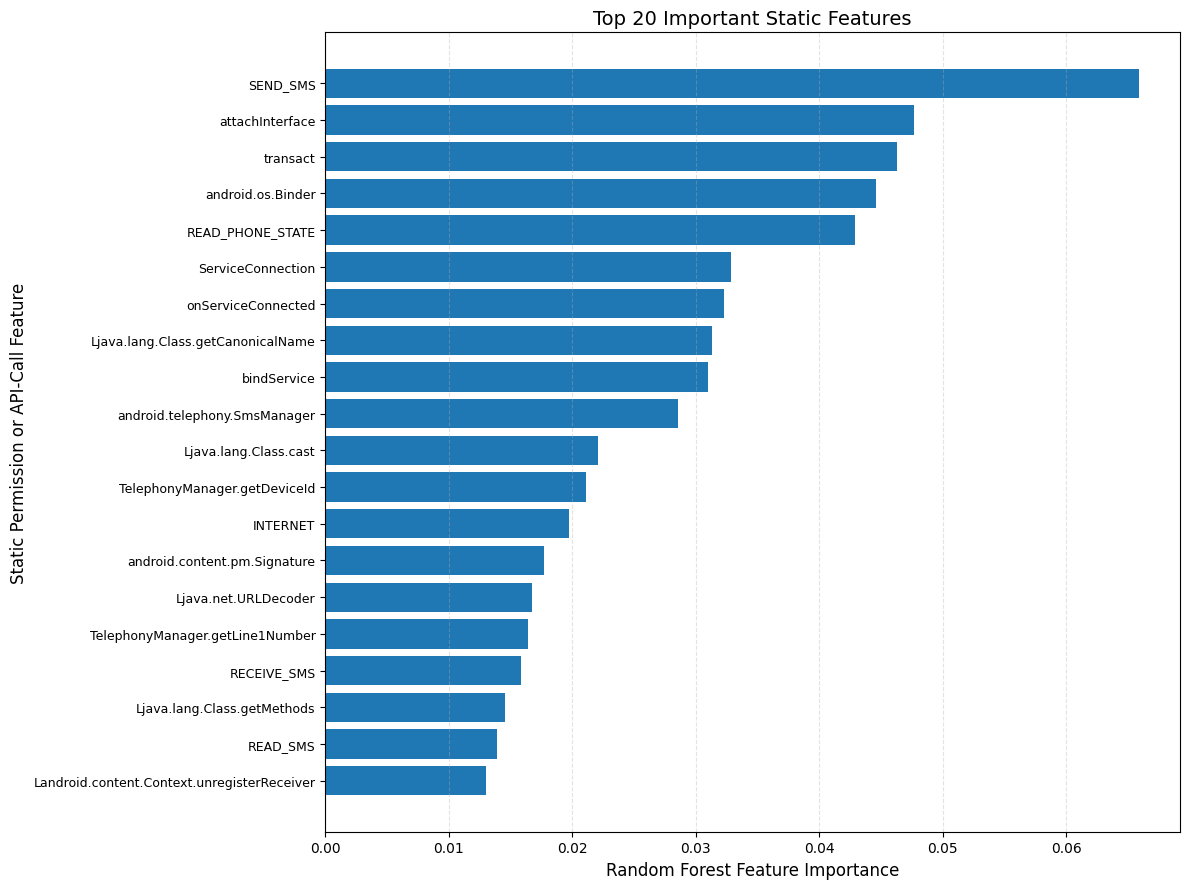

Figure saved:
/content/drive/MyDrive/BSc Thesis/final_outputs/Fig1_Top20_Feature_Importance.png

Top 20 features saved:


,Feature,Importance
6,SEND_SMS,0.065903
3,attachInterface,0.047636
0,transact,0.046260
5,android.os.Binder,0.044621
13,READ_PHONE_STATE,0.042896
4,ServiceConnection,0.032872
1,onServiceConnected,0.032314
7,Ljava.lang.Class.getCanonicalName,0.031346
2,bindService,0.030997
12,android.telephony.SmsManager,0.028558


In [15]:
rf_model = trained_models["Random Forest"]

feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

top20_features = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).head(20)

plot_top20 = top20_features.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(12, 9))

plt.barh(
    plot_top20["Feature"],
    plot_top20["Importance"],
    color="#1f77b4"
)

plt.xlabel("Random Forest Feature Importance", fontsize=12)
plt.ylabel("Static Permission or API-Call Feature", fontsize=12)
plt.title("Top 20 Important Static Features", fontsize=14)

plt.xticks(fontsize=10)
plt.yticks(fontsize=9)

plt.grid(axis="x", linestyle="--", alpha=0.35)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/Fig1_Top20_Feature_Importance.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

top20_features.to_csv(
    f"{OUTPUT_DIR}/top20_feature_importance.csv",
    index=False
)

print("Figure saved:")
print(f"{OUTPUT_DIR}/Fig1_Top20_Feature_Importance.png")

print("\nTop 20 features saved:")
display(top20_features)

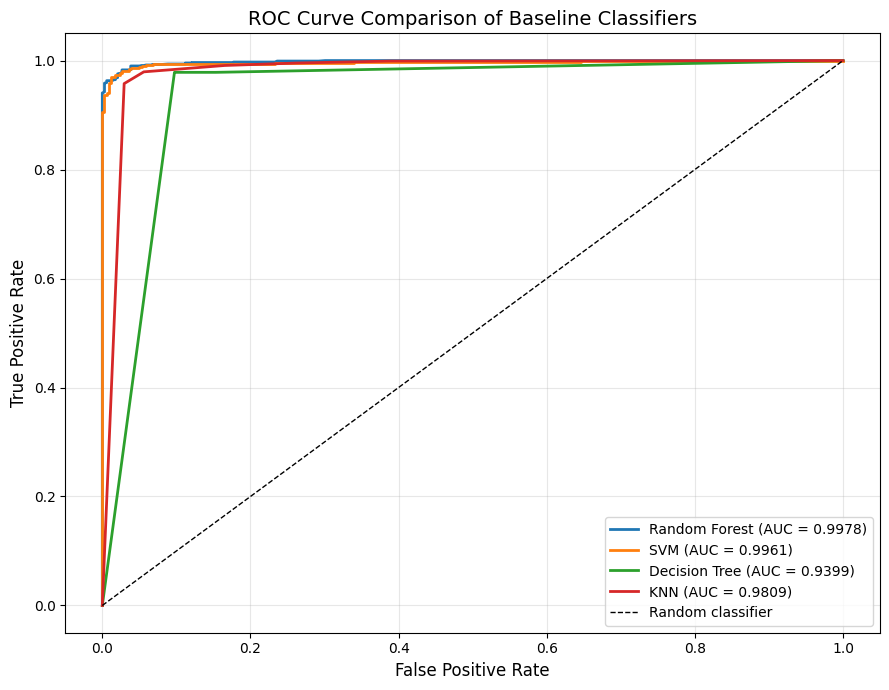

ROC curve saved:
/content/drive/MyDrive/BSc Thesis/final_outputs/Fig2_ROC_Curve_Comparison.png


In [16]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(9, 7))

for model_name, y_prob in test_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_value = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {auc_value:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    linewidth=1,
    label="Random classifier"
)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve Comparison of Baseline Classifiers", fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/Fig2_ROC_Curve_Comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("ROC curve saved:")
print(f"{OUTPUT_DIR}/Fig2_ROC_Curve_Comparison.png")

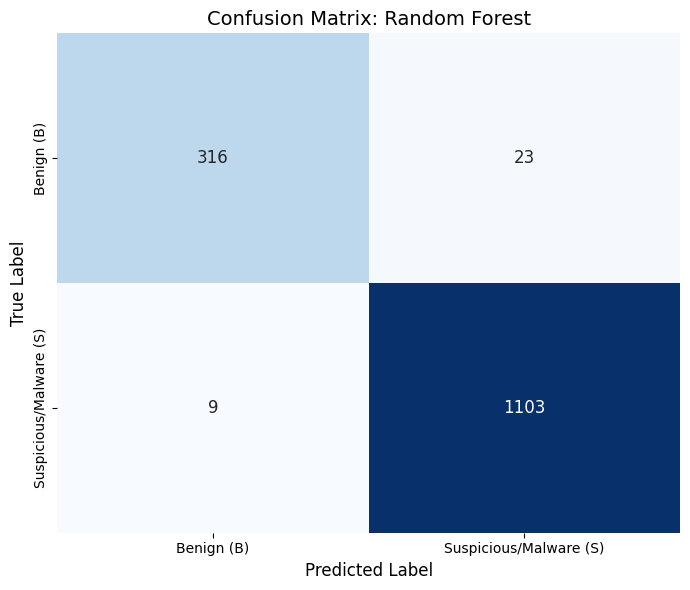

Random Forest confusion matrix:
[[ 316   23]
 [   9 1103]]

Figure saved:
/content/drive/MyDrive/BSc Thesis/final_outputs/Fig3_Confusion_Matrix_Random_Forest.png


In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

rf_predictions = test_predictions["Random Forest"]

rf_cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(7, 6))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Benign (B)", "Suspicious/Malware (S)"],
    yticklabels=["Benign (B)", "Suspicious/Malware (S)"],
    annot_kws={"size": 12}
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix: Random Forest", fontsize=14)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/Fig3_Confusion_Matrix_Random_Forest.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Random Forest confusion matrix:")
print(rf_cm)

print("\nFigure saved:")
print(f"{OUTPUT_DIR}/Fig3_Confusion_Matrix_Random_Forest.png")

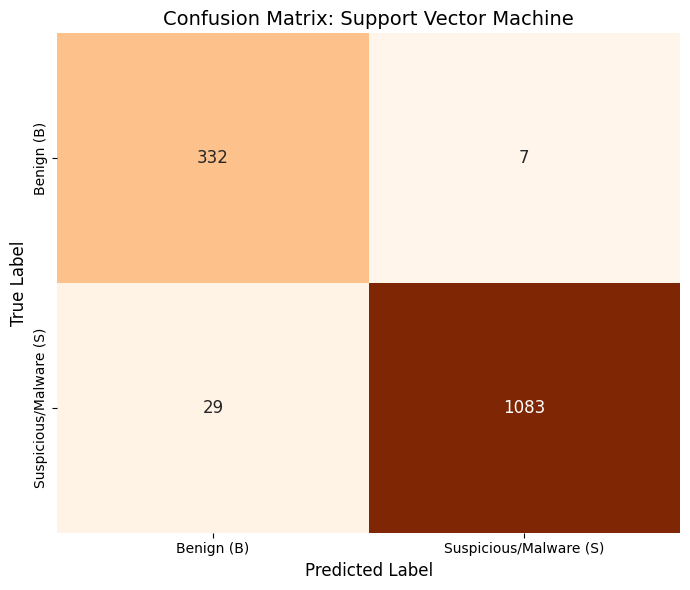

SVM confusion matrix:
[[ 332    7]
 [  29 1083]]

Figure saved:
/content/drive/MyDrive/BSc Thesis/final_outputs/Fig4_Confusion_Matrix_SVM.png


In [18]:
svm_predictions = test_predictions["SVM"]

svm_cm = confusion_matrix(y_test, svm_predictions)

plt.figure(figsize=(7, 6))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    cbar=False,
    xticklabels=["Benign (B)", "Suspicious/Malware (S)"],
    yticklabels=["Benign (B)", "Suspicious/Malware (S)"],
    annot_kws={"size": 12}
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix: Support Vector Machine", fontsize=14)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/Fig4_Confusion_Matrix_SVM.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("SVM confusion matrix:")
print(svm_cm)

print("\nFigure saved:")
print(f"{OUTPUT_DIR}/Fig4_Confusion_Matrix_SVM.png")

Total original features: 215
Components required for 95% explained variance: 140


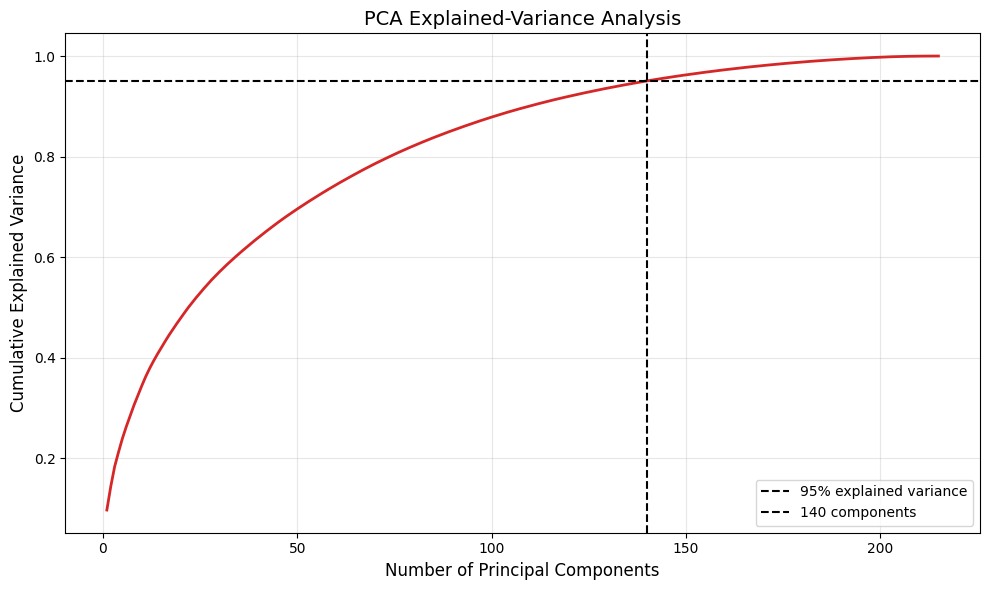


Figure saved:
/content/drive/MyDrive/BSc Thesis/final_outputs/Fig5_PCA_Explained_Variance.png


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PCA requires scaling because it is variance-based
pca_scaler = StandardScaler()

X_train_scaled_for_pca = pca_scaler.fit_transform(X_train)
X_test_scaled_for_pca = pca_scaler.transform(X_test)

# Fit PCA only on training data
max_components = min(
    X_train_scaled_for_pca.shape[0],
    X_train_scaled_for_pca.shape[1]
)

pca_full = PCA(
    n_components=max_components,
    random_state=42
)

pca_full.fit(X_train_scaled_for_pca)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

components_95 = int(
    np.argmax(cumulative_variance >= 0.95) + 1
)

print("Total original features:", X_train.shape[1])
print("Components required for 95% explained variance:", components_95)

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    linewidth=2,
    color="#d62728"
)

plt.axhline(
    y=0.95,
    color="black",
    linestyle="--",
    label="95% explained variance"
)

plt.axvline(
    x=components_95,
    color="black",
    linestyle="--",
    label=f"{components_95} components"
)

plt.xlabel("Number of Principal Components", fontsize=12)
plt.ylabel("Cumulative Explained Variance", fontsize=12)
plt.title("PCA Explained-Variance Analysis", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/Fig5_PCA_Explained_Variance.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

pca_summary = pd.DataFrame({
    "Number of Components": range(1, len(cumulative_variance) + 1),
    "Cumulative Explained Variance": cumulative_variance
})

pca_summary.to_csv(
    f"{OUTPUT_DIR}/pca_explained_variance.csv",
    index=False
)

print("\nFigure saved:")
print(f"{OUTPUT_DIR}/Fig5_PCA_Explained_Variance.png")

In [20]:
!pip -q install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 2.6 MB/s eta 0:00:00


In [21]:
from sklearn.decomposition import PCA

PCA_COMPONENTS_FOR_LAZY = 20

pca_lazy = PCA(
    n_components=PCA_COMPONENTS_FOR_LAZY,
    random_state=42
)

X_train_pca_lazy = pca_lazy.fit_transform(
    X_train_scaled_for_pca
)

X_test_pca_lazy = pca_lazy.transform(
    X_test_scaled_for_pca
)

print("LazyPredict PCA training shape:", X_train_pca_lazy.shape)
print("LazyPredict PCA test shape:", X_test_pca_lazy.shape)

print(
    "\nExplained variance retained by 20 components:",
    round(pca_lazy.explained_variance_ratio_.sum(), 4)
)

LazyPredict PCA training shape: (5803, 20)
LazyPredict PCA test shape: (1451, 20)

Explained variance retained by 20 components: 0.4788


In [22]:
from lazypredict.Supervised import LazyClassifier

lazy_classifier = LazyClassifier(
    verbose=0,
    ignore_warnings=True,
    custom_metric=None
)

lazy_models, lazy_predictions = lazy_classifier.fit(
    X_train_pca_lazy,
    X_test_pca_lazy,
    y_train,
    y_test
)

lazy_results = lazy_models.reset_index().rename(
    columns={"index": "Classifier"}
)

print("All available LazyPredict result columns:")
print(lazy_results.columns.tolist())

print("\nTop 10 classifiers by accuracy:")
display(
    lazy_results.sort_values(
        by="Accuracy",
        ascending=False
    ).head(10)
)

All available LazyPredict result columns:
['Model', 'Accuracy', 'Balanced Accuracy', 'ROC AUC', 'F1 Score', 'Precision', 'Recall', 'Time Taken']

Top 10 classifiers by accuracy:


,Model,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
0,LGBMClassifier,0.977946,0.963055,0.995663,0.977807,0.977855,0.977946,0.461948
1,ExtraTreesClassifier,0.973122,0.954781,0.997731,0.972908,0.972987,0.973122,1.176233
2,XGBClassifier,0.973122,0.954781,0.995092,0.972908,0.972987,0.973122,0.669926
3,BaggingClassifier,0.968987,0.946957,0.987649,0.968671,0.968825,0.968987,1.447671
4,RandomForestClassifier,0.968298,0.943432,0.995974,0.967885,0.968230,0.968298,3.220148
5,LabelSpreading,0.964852,0.939133,NaN,0.964415,0.964666,0.964852,5.138311
6,LabelPropagation,0.964163,0.937658,NaN,0.963696,0.963981,0.964163,4.079644
7,DecisionTreeClassifier,0.960028,0.931884,0.931919,0.959508,0.959732,0.960028,0.230554
8,SVC,0.952447,0.921812,0.982258,0.951855,0.951935,0.952447,0.977447
9,ExtraTreeClassifier,0.946244,0.917765,0.917455,0.945845,0.945688,0.946244,0.049408


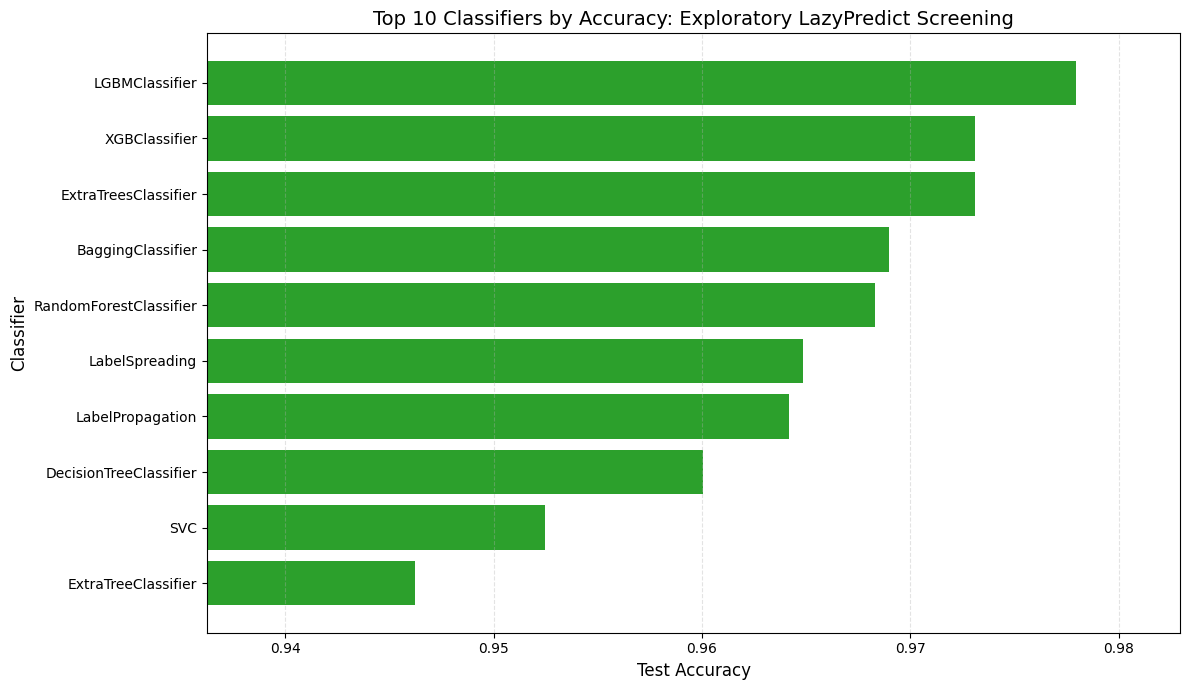

Figure saved:
/content/drive/MyDrive/BSc Thesis/final_outputs/Fig6_LazyPredict_Top10_Accuracy.png

Top 10 results:


,Model,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
0,LGBMClassifier,0.977946,0.963055,0.995663,0.977807,0.977855,0.977946,0.461948
1,ExtraTreesClassifier,0.973122,0.954781,0.997731,0.972908,0.972987,0.973122,1.176233
2,XGBClassifier,0.973122,0.954781,0.995092,0.972908,0.972987,0.973122,0.669926
3,BaggingClassifier,0.968987,0.946957,0.987649,0.968671,0.968825,0.968987,1.447671
4,RandomForestClassifier,0.968298,0.943432,0.995974,0.967885,0.968230,0.968298,3.220148
5,LabelSpreading,0.964852,0.939133,NaN,0.964415,0.964666,0.964852,5.138311
6,LabelPropagation,0.964163,0.937658,NaN,0.963696,0.963981,0.964163,4.079644
7,DecisionTreeClassifier,0.960028,0.931884,0.931919,0.959508,0.959732,0.960028,0.230554
8,SVC,0.952447,0.921812,0.982258,0.951855,0.951935,0.952447,0.977447
9,ExtraTreeClassifier,0.946244,0.917765,0.917455,0.945845,0.945688,0.946244,0.049408


In [23]:
lazy_top10 = lazy_results.sort_values(
    by="Accuracy",
    ascending=False
).head(10).copy()

lazy_top10.to_csv(
    f"{OUTPUT_DIR}/lazypredict_top10_results.csv",
    index=False
)

plot_lazy_top10 = lazy_top10.sort_values(
    by="Accuracy",
    ascending=True
)

plt.figure(figsize=(12, 7))

plt.barh(
    plot_lazy_top10["Model"],
    plot_lazy_top10["Accuracy"],
    color="#2ca02c"
)

plt.xlabel("Test Accuracy", fontsize=12)
plt.ylabel("Classifier", fontsize=12)
plt.title(
    "Top 10 Classifiers by Accuracy: Exploratory LazyPredict Screening",
    fontsize=14
)

x_min = max(0.90, plot_lazy_top10["Accuracy"].min() - 0.01)
x_max = min(1.00, plot_lazy_top10["Accuracy"].max() + 0.005)

plt.xlim(x_min, x_max)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis="x", linestyle="--", alpha=0.35)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/Fig6_LazyPredict_Top10_Accuracy.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:")
print(f"{OUTPUT_DIR}/Fig6_LazyPredict_Top10_Accuracy.png")

print("\nTop 10 results:")
display(lazy_top10)

In [24]:
import json
import sys
import platform
import sklearn
import matplotlib
import seaborn

experiment_details = {
    "dataset_file": os.path.basename(DATASET_PATH),
    "dataset_samples_before_removing_missing_label": 7255,
    "dataset_samples_used": int(len(y)),
    "target_column": TARGET_COLUMN,
    "class_mapping": {
        "0": "B (Benign)",
        "1": "S (Suspicious/Malware)"
    },
    "class_counts": {
        "B (Benign)": int((y == 0).sum()),
        "S (Suspicious/Malware)": int((y == 1).sum())
    },
    "number_of_static_features": int(X.shape[1]),
    "data_split": "Stratified 80:20 train-test split",
    "training_samples": int(len(y_train)),
    "test_samples": int(len(y_test)),
    "random_state": 42,
    "cross_validation": "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)",
    "main_models": [
        "Random Forest",
        "Support Vector Machine",
        "Decision Tree",
        "K-Nearest Neighbors"
    ],
    "hyperparameter_tuning": (
        "No GridSearchCV or RandomizedSearchCV was used for the "
        "primary four-model baseline comparison; fixed documented "
        "configurations were used."
    ),
    "pca_analysis": {
        "original_features": 215,
        "components_for_95_percent_variance": int(components_95),
        "lazy_predict_components": 20,
        "lazy_predict_variance_retained": round(
            float(pca_lazy.explained_variance_ratio_.sum()), 4
        )
    },
    "python_version": sys.version,
    "platform": platform.platform(),
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "scikit_learn_version": sklearn.__version__,
    "matplotlib_version": matplotlib.__version__,
    "seaborn_version": seaborn.__version__
}

details_path = f"{OUTPUT_DIR}/experiment_details.json"

with open(details_path, "w") as file:
    json.dump(experiment_details, file, indent=4)

print("Experiment details saved successfully:")
print(details_path)

print("\nAll final output files currently in final_outputs:")
for file_name in sorted(os.listdir(OUTPUT_DIR)):
    print("-", file_name)

Experiment details saved successfully:
/content/drive/MyDrive/BSc Thesis/final_outputs/experiment_details.json

All final output files currently in final_outputs:
- Fig1_Top20_Feature_Importance.png
- Fig2_ROC_Curve_Comparison.png
- Fig3_Confusion_Matrix_Random_Forest.png
- Fig4_Confusion_Matrix_SVM.png
- Fig5_PCA_Explained_Variance.png
- Fig6_LazyPredict_Top10_Accuracy.png
- experiment_details.json
- final_model_performance.csv
- lazypredict_top10_results.csv
- pca_explained_variance.csv
- top20_feature_importance.csv
